# Hotel Booking Cancellation Prediction using Machine Learning

## Objective
Predict whether a hotel booking will be canceled or not.

## Import Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [17]:
df = pd.read_csv("cleaned_data.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,total_stay,Revenue,Total_Previous_Bookings,Cancellation_Rate,Booking_Change_Rate,res_year,res_month,res_day,res_weekday,pricepernight
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,0.0,0,0.0,0.008746,2015,7,1,2,0.000000
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,0.0,0,0.0,0.005420,2015,7,1,2,0.000000
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,1,75.0,0,0.0,0.000000,2015,7,2,3,37.500000
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,1,75.0,0,0.0,0.000000,2015,7,2,3,37.500000
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,2,196.0,0,0.0,0.000000,2015,7,3,4,32.666667


## Data Understanding

In [18]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 40 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,total_stay,Revenue,Total_Previous_Bookings,Cancellation_Rate,Booking_Change_Rate,res_year,res_month,res_day,res_weekday,pricepernight
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,...,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,...,3.427900,357.848208,0.224215,0.026124,0.023670,2016.093743,6.334123,15.666639,2.885267,28.032286
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,...,2.557439,335.910109,1.827956,0.112904,0.176265,0.715306,3.346352,8.778432,1.984289,19.649550
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,-63.800000,0.000000,0.000000,0.000000,2014.000000,1.000000,1.000000,0.000000,-0.580000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,2.000000,146.000000,0.000000,0.000000,0.000000,2016.000000,3.000000,8.000000,1.000000,16.250000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,...,3.000000,267.000000,0.000000,0.000000,0.000000,2016.000000,6.000000,16.000000,3.000000,23.970000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,...,4.000000,446.250000,0.000000,0.000000,0.000000,2017.000000,9.000000,23.000000,4.000000,35.700000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,...,69.000000,7590.000000,78.000000,0.962963,20.000000,2017.000000,12.000000,31.000000,6.000000,2700.000000


## Data Cleaning

In [19]:
df.isnull().sum()
df = df.dropna()

## Exploratory Data Analysis

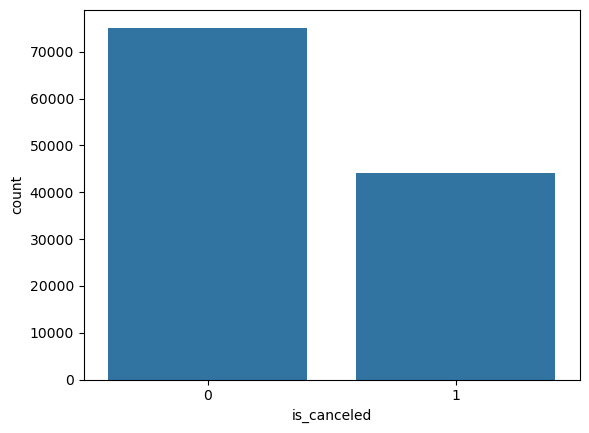

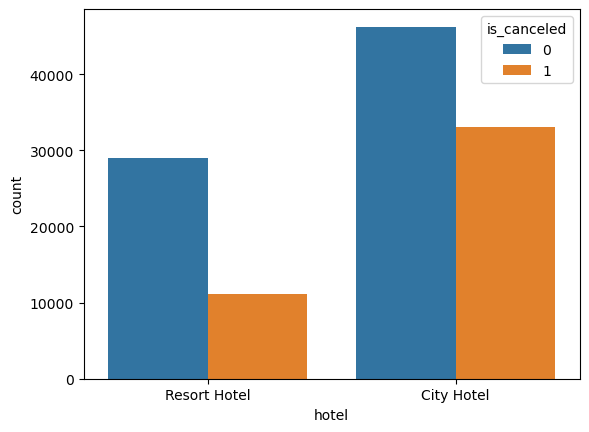

In [20]:
sns.countplot(x='is_canceled', data=df)
plt.show()

sns.countplot(x='hotel', hue='is_canceled', data=df)
plt.show()

## Feature Selection

In [21]:
X = df.drop("is_canceled", axis=1)
y = df["is_canceled"]

## Encode Categorical Variables

In [22]:
X = pd.get_dummies(X, drop_first=True)
X

,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,...,reservation_status_date_9/6/2017,reservation_status_date_9/7/2015,reservation_status_date_9/7/2016,reservation_status_date_9/7/2017,reservation_status_date_9/8/2015,reservation_status_date_9/8/2016,reservation_status_date_9/8/2017,reservation_status_date_9/9/2015,reservation_status_date_9/9/2016,reservation_status_date_9/9/2017
0,342,2015,27,1,0,0,2,0.0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,737,2015,27,1,0,0,2,0.0,0,0,...,False,False,False,False,False,False,False,False,False,False
2,7,2015,27,1,0,1,1,0.0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,13,2015,27,1,0,1,1,0.0,0,0,...,False,False,False,False,False,False,False,False,False,False
4,14,2015,27,1,0,2,2,0.0,0,0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,23,2017,35,30,2,5,2,0.0,0,0,...,True,False,False,False,False,False,False,False,False,False
119386,102,2017,35,31,2,5,3,0.0,0,0,...,False,False,False,True,False,False,False,False,False,False
119387,34,2017,35,31,2,5,2,0.0,0,0,...,False,False,False,True,False,False,False,False,False,False
119388,109,2017,35,31,2,5,2,0.0,0,0,...,False,False,False,True,False,False,False,False,False,False


In [23]:
y

0         0
1         0
2         0
3         0
4         0
         ..
119385    0
119386    0
119387    0
119388    0
119389    0
Name: is_canceled, Length: 119386, dtype: int64

## Train-Test Split

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train

,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,...,reservation_status_date_9/6/2017,reservation_status_date_9/7/2015,reservation_status_date_9/7/2016,reservation_status_date_9/7/2017,reservation_status_date_9/8/2015,reservation_status_date_9/8/2016,reservation_status_date_9/8/2017,reservation_status_date_9/9/2015,reservation_status_date_9/9/2016,reservation_status_date_9/9/2017
67705,162,2017,18,6,2,1,1,0.0,0,0,...,False,False,False,False,False,False,False,False,False,False
115852,65,2017,28,10,1,1,2,2.0,0,0,...,False,False,False,False,False,False,False,False,False,False
57349,254,2016,39,24,1,1,2,0.0,0,0,...,False,False,False,False,False,False,False,False,False,False
11622,251,2017,21,21,2,4,2,0.0,0,0,...,False,False,False,False,False,False,False,False,False,False
33333,23,2017,7,18,1,1,2,0.0,0,0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76824,3,2015,34,20,0,1,2,1.0,0,1,...,False,False,False,False,False,False,False,False,False,False
110272,67,2017,16,22,2,1,2,0.0,0,0,...,False,False,False,False,False,False,False,False,False,False
103698,103,2016,53,27,0,3,3,0.0,0,0,...,False,False,False,False,False,False,False,False,False,False
860,130,2015,31,1,2,5,2,0.0,0,0,...,False,False,False,False,False,False,False,False,False,False


## Feature Scaling

In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
y_train

67705     1
115852    0
57349     1
11622     1
33333     0
         ..
76824     0
110272    0
103698    0
860       1
15795     0
Name: is_canceled, Length: 95508, dtype: int64

In [27]:
X_test

array([[ 0.92577281, -0.22142734,  1.60407338, ..., -0.04934603,
        -0.03472088, -0.00457614],
       [-0.205619  , -1.63573099,  0.13475378, ..., -0.04934603,
        -0.03472088, -0.00457614],
       [ 0.16839482,  1.19287631, -0.89376994, ..., -0.04934603,
        -0.03472088, -0.00457614],
       ...,
       [-0.59833352,  1.19287631, -1.7753617 , ..., -0.04934603,
        -0.03472088, -0.00457614],
       [-0.962997  , -1.63573099,  0.7959476 , ..., -0.04934603,
        -0.03472088, -0.00457614],
       [ 0.60786106, -0.22142734, -0.74683798, ..., -0.04934603,
        -0.03472088, -0.00457614]])

In [28]:
y_test

30946     0
40207     1
110028    0
67743     1
109993    0
         ..
48380     1
19712     0
32188     0
77306     0
50040     1
Name: is_canceled, Length: 23878, dtype: int64

## Model Building

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Prediction

In [30]:
y_pred = model.predict(X_test)
y_pred

array([0, 1, 0, ..., 0, 0, 1])

## Model Evaluation

In [31]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
[[14973     0]
 [    0  8905]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     14973
           1       1.00      1.00      1.00      8905

    accuracy                           1.00     23878
   macro avg       1.00      1.00      1.00     23878
weighted avg       1.00      1.00      1.00     23878



## ROC-AUC Curve

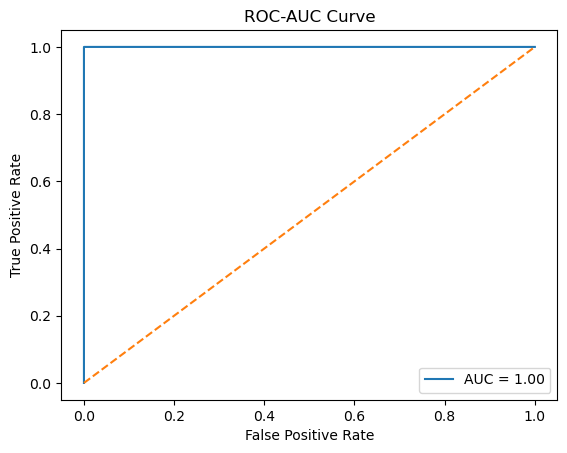

In [32]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC score
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend()
plt.show()

##### This graph shows the performance of the classification model in distinguishing between cancelled and non-cancelled bookings.

- The curve plots True Positive Rate (TPR) against False Positive Rate (FPR)

- The diagonal line represents a random model

- The AUC score indicates model performance

- A curve closer to the top-left corner and a higher AUC value represent a better model

## Insights
- Longer lead time increases cancellation
- City hotels have more cancellations
- No deposit bookings are risky

## Conclusion
Model predicts booking cancellations effectively.